In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt

import torch

from dataset.dataset import SegmentationDataset
from dataset.datamodule import SegmentationModule
from utils.albumentation import augment

In [75]:
root = Path("C:/Users/Administrator/PythonProjects/landcover_classification/ML_datasets/FLAIR1/flair_1_toy_dataset")
train_images_dir = root / "flair_1_toy_aerial_train"
# train_masks_dir = root / "flair_1_toy_labels_train"

# images = [p for p in train_images_dir.rglob("*.tif")]
# masks = [p for p in train_masks_dir.rglob("*.tif")]

# print(f"Len images: {len(images)}")
# print(f"Len masks: {len(masks)}")

In [76]:
model = SegmentationModule(
    data_dir=root,
    num_classes=15,
    in_channels=5,
    ignore_index=0,
    augment=augment,
    batch_size=16,
    num_workers=4,
)

In [77]:
model.setup(stage="fit")

200
len full data200


In [78]:
train_dataset = model.train_dataset
train_dataset.__len__()

160

In [79]:
img, msk = train_dataset.__getitem__(0)
print(img.shape)
print(torch.min(img))
print(torch.max(img))

img = img[:3, ...].permute(1,2,0)

(512, 512, 5)
(512, 512)
torch.Size([5, 512, 512])
tensor(0.)
tensor(1.)


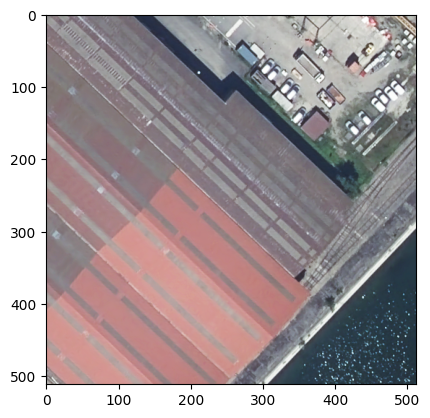

In [80]:
plt.imshow(img)

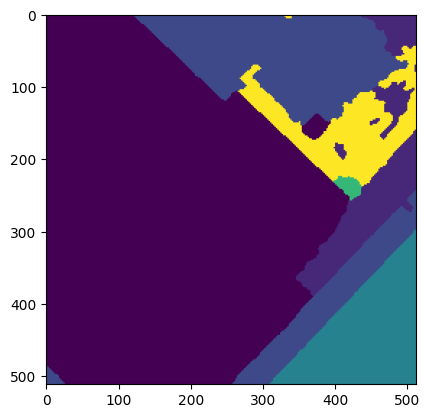

In [81]:
plt.imshow(msk)